# 09. Mieterhöhung Rules — §558 BGB Validation

**What:** Landlords can raise rent on *existing tenants* up to the Mietspiegel mid value, subject to a cap (Kappungsgrenze) and timing constraints. This is separate from the Mietpreisbremse (§556d, which governs new leases).

**Rules:**
1. Max rent = Mietspiegel mid value (ortsübliche Vergleichsmiete)
2. Kappungsgrenze: max 15% increase within any 3-year period (Berlin uses 15%, federal default 20%)
3. 15-month minimum between rent increase requests
4. Formal written request required (Mieterhöhungsverlangen)

**This notebook:** Validates our §558 calculation against edge cases using Berlin apartments from our dataset.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from datetime import date, timedelta
from backend.services.compliance_service import lookup_mietspiegel, check_compliance
from backend.models.compliance import ComplianceInput, MietspiegelLookup

# Berlin Kappungsgrenze: 15% over 3 years (stricter than federal 20%)
KAPPUNGSGRENZE_PCT = 0.15
MIN_MONTHS_BETWEEN = 15

def _mietspiegel_mid(building_year, living_space_sqm, district, **equipment):
    """Helper: get Mietspiegel mid value using ComplianceInput."""
    inp = ComplianceInput(
        district=district,
        living_space_sqm=living_space_sqm,
        building_year=building_year,
        **{k: v for k, v in equipment.items() if v is not None}
    )
    ms = lookup_mietspiegel(inp)
    return ms.adjusted_mid

def calculate_mieterhoehung(
    current_rent_sqm: float,
    living_space_sqm: float,
    building_year: int,
    district: str,
    rent_3_years_ago: float = None,
    last_increase_date: date = None,
    **equipment_flags
):
    """Calculate maximum §558 BGB rent increase."""
    
    # Step 1: Look up Mietspiegel mid value
    mietspiegel_mid = _mietspiegel_mid(building_year, living_space_sqm, district, **equipment_flags)
    
    # Step 2: Max from Mietspiegel (can't exceed mid value)
    max_from_ms = mietspiegel_mid
    
    # Step 3: Kappungsgrenze (15% cap over 3 years)
    max_from_kappung = None
    if rent_3_years_ago:
        max_from_kappung = round(rent_3_years_ago * (1 + KAPPUNGSGRENZE_PCT), 2)
    
    # Step 4: Effective max = lower of both constraints
    if max_from_kappung is not None:
        effective_max = min(max_from_ms, max_from_kappung)
        binding_constraint = "kappungsgrenze" if max_from_kappung < max_from_ms else "mietspiegel"
    else:
        effective_max = max_from_ms
        binding_constraint = "mietspiegel"
    
    max_increase = max(0, round(effective_max - current_rent_sqm, 2))
    
    # Step 5: Timing check
    can_increase_now = True
    earliest_date = None
    if last_increase_date:
        earliest_date = last_increase_date + timedelta(days=MIN_MONTHS_BETWEEN * 30)
        can_increase_now = date.today() >= earliest_date
    
    return {
        "current_rent_sqm": current_rent_sqm,
        "mietspiegel_mid": mietspiegel_mid,
        "max_from_mietspiegel": max_from_ms,
        "max_from_kappungsgrenze": max_from_kappung,
        "binding_constraint": binding_constraint,
        "effective_max_rent": round(effective_max, 2),
        "max_increase_sqm": max_increase,
        "max_increase_total": round(max_increase * living_space_sqm, 2),
        "max_increase_annual": round(max_increase * living_space_sqm * 12, 2),
        "can_increase_now": can_increase_now,
        "earliest_date": earliest_date,
    }

print("Mieterhoehung calculator loaded.")

Mieterhoehung calculator loaded.


## Test Cases — Edge Cases for §558 BGB

In [2]:
# Test 1: Standard case — rent below Mietspiegel mid, no prior increase
print("=" * 60)
print("TEST 1: Standard increase — Kreuzberg Altbau, rent below mid")
print("=" * 60)
result = calculate_mieterhoehung(
    current_rent_sqm=6.50,
    living_space_sqm=75,
    building_year=1912,
    district="Friedrichshain-Kreuzberg",
)
for k, v in result.items():
    print(f"  {k}: {v}")
assert result["max_increase_sqm"] > 0, "Should allow increase"
assert result["can_increase_now"] == True
print("\n  PASS: Increase allowed to Mietspiegel mid")

# Test 2: Rent already at or above Mietspiegel mid — no increase possible
print("\n" + "=" * 60)
print("TEST 2: Rent already at Mietspiegel mid — no increase")
print("=" * 60)
result = calculate_mieterhoehung(
    current_rent_sqm=9.00,
    living_space_sqm=75,
    building_year=1912,
    district="Friedrichshain-Kreuzberg",
)
for k, v in result.items():
    print(f"  {k}: {v}")
assert result["max_increase_sqm"] == 0, "Should not allow increase"
print("\n  PASS: No increase allowed (rent >= Mietspiegel mid)")

# Test 3: Kappungsgrenze is the binding constraint
print("\n" + "=" * 60)
print("TEST 3: Kappungsgrenze binds — recent 3yr rent limits increase")
print("=" * 60)
result = calculate_mieterhoehung(
    current_rent_sqm=6.50,
    living_space_sqm=75,
    building_year=1912,
    district="Friedrichshain-Kreuzberg",
    rent_3_years_ago=6.00,  # 15% of €6.00 = max €6.90
)
for k, v in result.items():
    print(f"  {k}: {v}")
assert result["binding_constraint"] == "kappungsgrenze", "Kappungsgrenze should bind"
assert result["effective_max_rent"] == 6.90, f"Expected 6.90, got {result['effective_max_rent']}"
print("\n  PASS: Kappungsgrenze binds at 15% (max €6.90, not Mietspiegel mid)")

# Test 4: 15-month timing constraint
print("\n" + "=" * 60)
print("TEST 4: Too soon — last increase was 6 months ago")
print("=" * 60)
result = calculate_mieterhoehung(
    current_rent_sqm=6.50,
    living_space_sqm=75,
    building_year=1912,
    district="Friedrichshain-Kreuzberg",
    last_increase_date=date.today() - timedelta(days=180),  # 6 months ago
)
for k, v in result.items():
    print(f"  {k}: {v}")
assert result["can_increase_now"] == False, "Should not allow increase yet"
print(f"\n  PASS: Increase blocked until {result['earliest_date']}")

# Test 5: Timing OK — last increase was 18 months ago
print("\n" + "=" * 60)
print("TEST 5: Timing OK — last increase was 18 months ago")
print("=" * 60)
result = calculate_mieterhoehung(
    current_rent_sqm=6.50,
    living_space_sqm=75,
    building_year=1912,
    district="Friedrichshain-Kreuzberg",
    last_increase_date=date.today() - timedelta(days=550),  # ~18 months ago
)
assert result["can_increase_now"] == True
print("  PASS: Increase allowed (18 months since last increase)")

TEST 1: Standard increase — Kreuzberg Altbau, rent below mid
  current_rent_sqm: 6.5
  mietspiegel_mid: 7.57
  max_from_mietspiegel: 7.57
  max_from_kappungsgrenze: None
  binding_constraint: mietspiegel
  effective_max_rent: 7.57
  max_increase_sqm: 1.07
  max_increase_total: 80.25
  max_increase_annual: 963.0
  can_increase_now: True
  earliest_date: None

  PASS: Increase allowed to Mietspiegel mid

TEST 2: Rent already at Mietspiegel mid — no increase
  current_rent_sqm: 9.0
  mietspiegel_mid: 7.57
  max_from_mietspiegel: 7.57
  max_from_kappungsgrenze: None
  binding_constraint: mietspiegel
  effective_max_rent: 7.57
  max_increase_sqm: 0
  max_increase_total: 0
  max_increase_annual: 0
  can_increase_now: True
  earliest_date: None

  PASS: No increase allowed (rent >= Mietspiegel mid)

TEST 3: Kappungsgrenze binds — recent 3yr rent limits increase
  current_rent_sqm: 6.5
  mietspiegel_mid: 7.57
  max_from_mietspiegel: 7.57
  max_from_kappungsgrenze: 6.9
  binding_constraint: kap

## Portfolio-Level Analysis — How Many Units Are Eligible for §558 Increase?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/listings_clean.parquet")
print(f"Loaded {len(df):,} Berlin listings")

# For each apartment, check if current rent is below Mietspiegel mid
results = []
for _, row in df.iterrows():
    try:
        mid = _mietspiegel_mid(
            building_year=int(row["yearConstructed"]),
            living_space_sqm=float(row["livingSpace"]),
            district=str(row["bezirk"]),
        )
        current = float(row["rent_sqm"])
        headroom = max(0, mid - current)
        results.append({
            "rent_sqm": current,
            "mietspiegel_mid": mid,
            "headroom_sqm": headroom,
            "can_increase": headroom > 0,
            "headroom_total_monthly": headroom * float(row["livingSpace"]),
            "headroom_annual": headroom * float(row["livingSpace"]) * 12,
            "bezirk": row["bezirk"],
            "livingSpace": row["livingSpace"],
        })
    except Exception:
        pass

df_increase = pd.DataFrame(results)
print(f"\nAnalyzed {len(df_increase):,} apartments for s558 eligibility\n")

eligible = df_increase[df_increase["can_increase"]]
pct = len(eligible) / len(df_increase) * 100
print(f"Eligible for s558 increase: {len(eligible):,} ({pct:.1f}%)")
print(f"Not eligible (already at or above mid): {len(df_increase) - len(eligible):,} ({100-pct:.1f}%)")
print(f"\nAmong eligible apartments:")
print(f"  Mean headroom: {eligible['headroom_sqm'].mean():.2f} EUR/m2")
print(f"  Median headroom: {eligible['headroom_sqm'].median():.2f} EUR/m2")
print(f"  Mean monthly uplift: {eligible['headroom_total_monthly'].mean():.0f} EUR")
print(f"  Mean annual uplift: {eligible['headroom_annual'].mean():.0f} EUR")
print(f"\nTotal uncaptured revenue (all eligible):")
print(f"  Monthly: {eligible['headroom_total_monthly'].sum():,.0f} EUR")
print(f"  Annual: {eligible['headroom_annual'].sum():,.0f} EUR")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\danny\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\danny\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\danny\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\danny\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\danny\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\danny\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\danny\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\danny\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

Loaded 10,275 Berlin listings

Analyzed 8,914 apartments for s558 eligibility

Eligible for s558 increase: 845 (9.5%)
Not eligible (already at or above mid): 8,069 (90.5%)

Among eligible apartments:
  Mean headroom: 1.19 EUR/m2
  Median headroom: 0.80 EUR/m2
  Mean monthly uplift: 81 EUR
  Mean annual uplift: 976 EUR

Total uncaptured revenue (all eligible):
  Monthly: 68,735 EUR
  Annual: 824,816 EUR


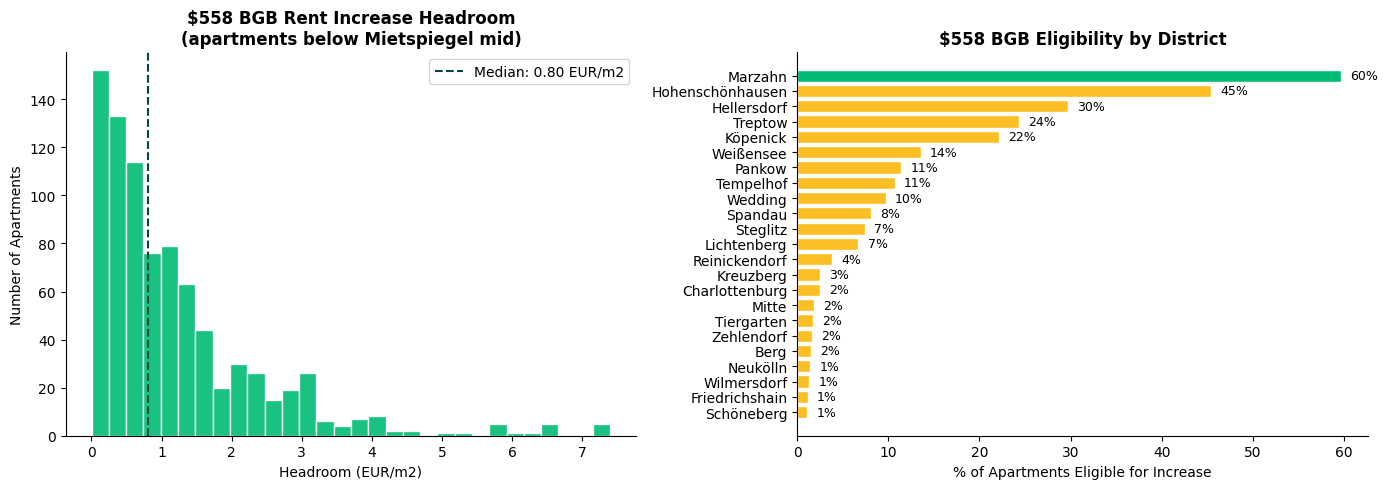

Saved: data/processed/mieterhoehung_eligibility.png


In [4]:
# Visualize: headroom distribution + by district
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Headroom distribution
ax = axes[0]
ax.hist(eligible["headroom_sqm"], bins=30, color="#00BC72", edgecolor="white", alpha=0.9)
ax.axvline(eligible["headroom_sqm"].median(), color="#004746", linestyle="--", linewidth=1.5,
           label=f"Median: {eligible['headroom_sqm'].median():.2f} EUR/m2")
ax.set_xlabel("Headroom (EUR/m2)")
ax.set_ylabel("Number of Apartments")
ax.set_title("$558 BGB Rent Increase Headroom\n(apartments below Mietspiegel mid)", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

# Right: By district
ax = axes[1]
district_stats = df_increase.groupby("bezirk").agg(
    eligible_pct=("can_increase", "mean"),
    mean_headroom=("headroom_sqm", "mean"),
    count=("can_increase", "count")
).sort_values("eligible_pct", ascending=True)

colors = ["#00BC72" if p > 0.5 else "#fbbf24" for p in district_stats["eligible_pct"]]
ax.barh(district_stats.index, district_stats["eligible_pct"] * 100, color=colors, edgecolor="white")
for i, (idx, row) in enumerate(district_stats.iterrows()):
    ax.text(row["eligible_pct"] * 100 + 1, i, f"{row['eligible_pct']*100:.0f}%", va="center", fontsize=9)
ax.set_xlabel("% of Apartments Eligible for Increase")
ax.set_title("$558 BGB Eligibility by District", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../data/processed/mieterhoehung_eligibility.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/processed/mieterhoehung_eligibility.png")